In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

# Настройка визуализации
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [7]:
# Загружаем данные (укажите свой путь к файлу)
df = pd.read_csv(r"C:\Users\user\Desktop\WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Первичный осмотр
print("Размер данных:", df.shape)
print("\nПервые 5 строк:")
df.head()

Размер данных: (7043, 21)

Первые 5 строк:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
# Информация о данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
# Описательная статистика для числовых колонок
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


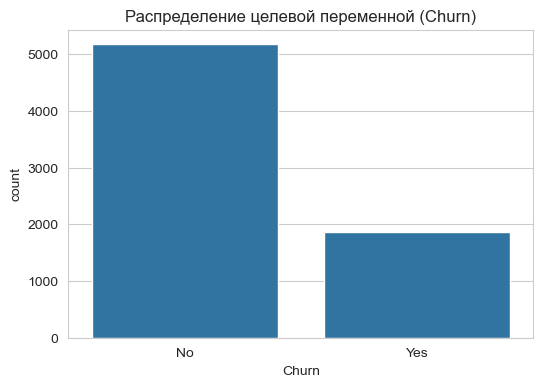

Доля ушедших клиентов: 26.54 %


C:\Users\user\AppData\Local\Temp\ipykernel_2648\2448811501.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("Доля ушедших клиентов:", round(df['Churn'].value_counts(normalize=True)[1] * 100, 2), '%')


In [13]:
# Баланс классов (целевая переменная)
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title('Распределение целевой переменной (Churn)')
plt.show()

print("Доля ушедших клиентов:", round(df['Churn'].value_counts(normalize=True)[1] * 100, 2), '%')

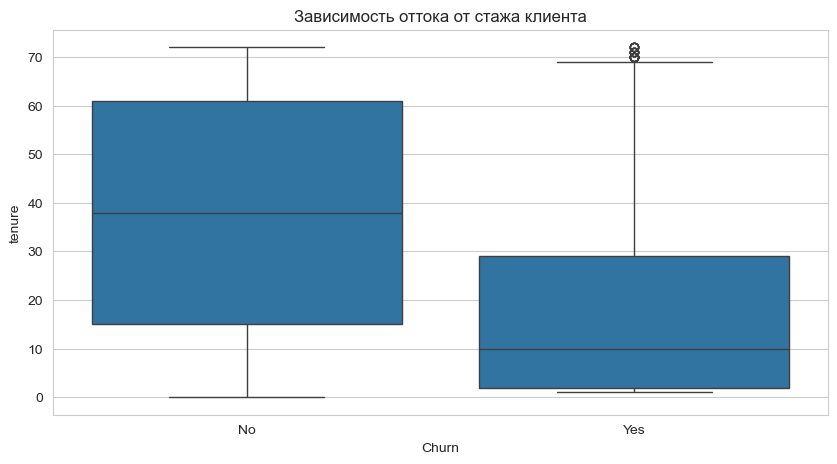

In [15]:
# Влияние стажа (tenure) на отток
plt.figure(figsize=(10,5))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Зависимость оттока от стажа клиента')
plt.show()

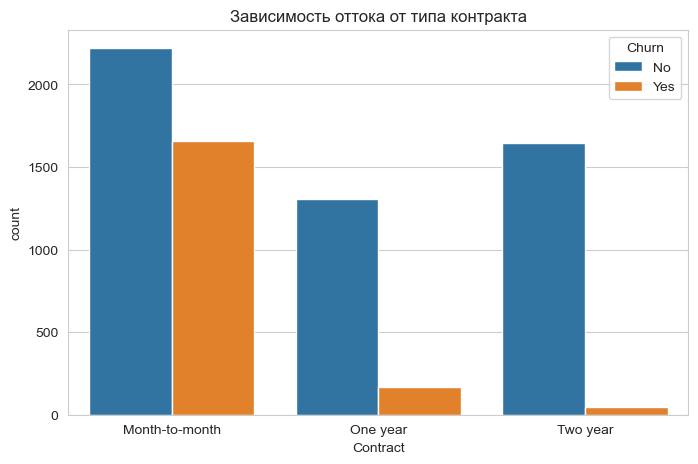

In [17]:
# Влияние типа контракта
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Зависимость оттока от типа контракта')
plt.show()

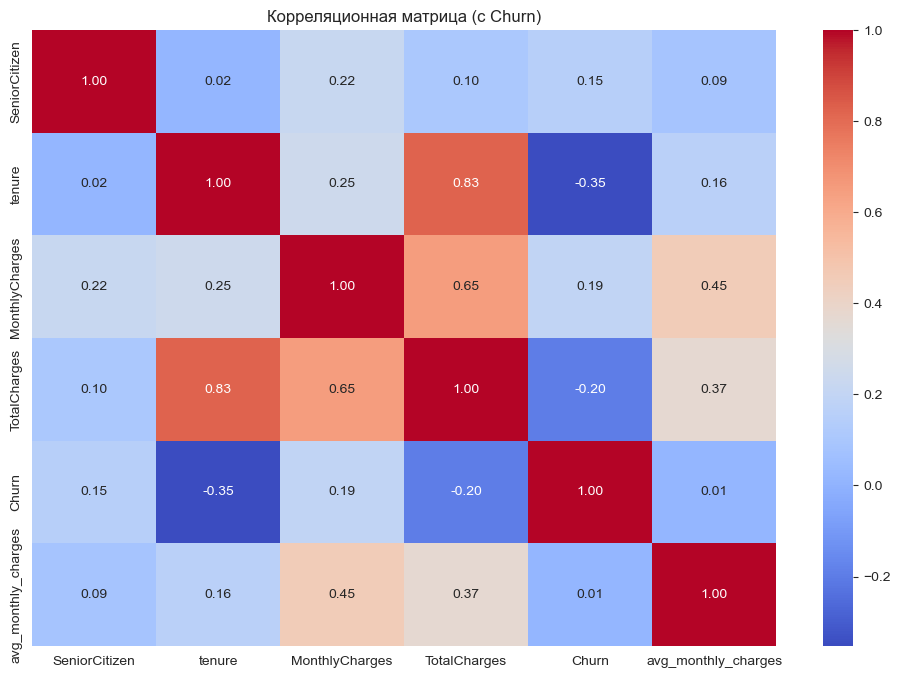

In [61]:
# Выбираем только числовые колонки
numeric_df = df.select_dtypes(include=[np.number])

# Строим корреляционную матрицу
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица (с Churn)')
plt.show()

In [21]:
#  Превращаем TotalCharges в число (там есть пробелы)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Проверяем пропуски
print("Пропуски в колонках:")
print(df.isnull().sum())

Пропуски в колонках:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [23]:
# Заполняем пропуски медианой (их очень мало)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_2648\1050083224.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [25]:
# Удаляем customerID (не нужен для модели)
df.drop('customerID', axis=1, inplace=True)

In [27]:
# Превращаем целевую переменную в 0/1
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [29]:
# Создаем новый признак: среднемесячный платёж (CLV)
df['avg_monthly_charges'] = df['TotalCharges'] / (df['tenure'] + 1)  # +1 чтобы не делить на 0

In [31]:
# Создаем список категориальных признаков для One-Hot Encoding
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Категориальные признаки:", categorical_cols)

Категориальные признаки: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [33]:
# One-Hot Encoding для категориальных переменных
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [35]:
# Проверяем размер после кодирования
print("Размер данных после кодирования:", df_encoded.shape)

Размер данных после кодирования: (7043, 32)


In [37]:
# Отделяем признаки (X) от целевой переменной (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [39]:
# Масштабируем числовые признаки
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [41]:
# Делим на обучающую (80%) и тестовую (20%) выборки
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (5634, 31)
Размер тестовой выборки: (1409, 31)


In [43]:
# Обучение
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

# Предсказания
y_pred_lr = lr.predict(X_test)
y_pred_proba_lr = lr.predict_proba(X_test)[:, 1]

# Метрики
print("===== ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ =====")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba_lr), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

===== ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ =====
Accuracy: 0.8126
ROC-AUC: 0.8625

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.55      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.81      1409



In [45]:
# Обучение
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Предсказания
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:, 1]

# Метрики
print("===== СЛУЧАЙНЫЙ ЛЕС =====")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba_rf), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

===== СЛУЧАЙНЫЙ ЛЕС =====
Accuracy: 0.7963
ROC-AUC: 0.8379

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.87      1036
           1       0.65      0.50      0.56       373

    accuracy                           0.80      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.80      0.79      1409



In [47]:
# Обучение
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

# Предсказания
y_pred_xgb = xgb.predict(X_test)
y_pred_proba_xgb = xgb.predict_proba(X_test)[:, 1]

# Метрики
print("===== XGBOOST =====")
print("Accuracy:", round(accuracy_score(y_test, y_pred_xgb), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba_xgb), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

===== XGBOOST =====
Accuracy: 0.8034
ROC-AUC: 0.8586

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1036
           1       0.66      0.54      0.59       373

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



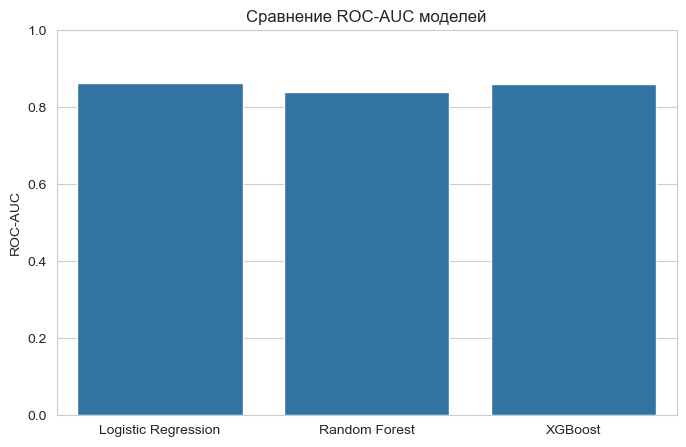

In [49]:
# Сравнение ROC-AUC всех моделей
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
auc_scores = [
    roc_auc_score(y_test, y_pred_proba_lr),
    roc_auc_score(y_test, y_pred_proba_rf),
    roc_auc_score(y_test, y_pred_proba_xgb)
]

plt.figure(figsize=(8,5))
sns.barplot(x=models, y=auc_scores)
plt.ylim(0, 1)
plt.title('Сравнение ROC-AUC моделей')
plt.ylabel('ROC-AUC')
plt.show()

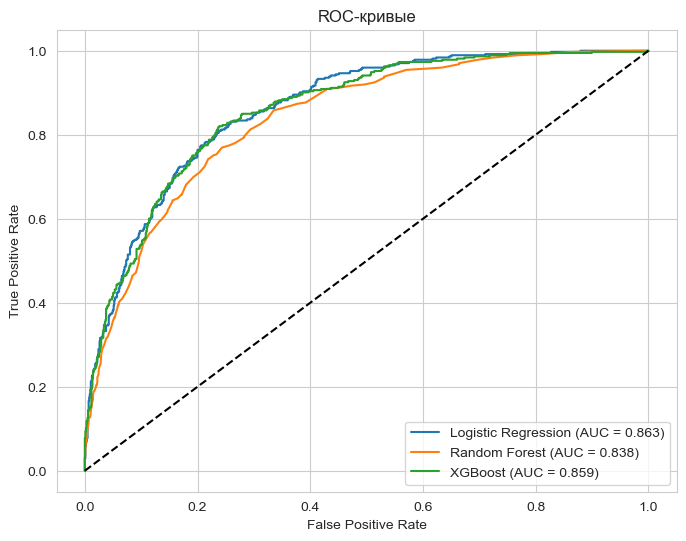

In [51]:
# ROC-кривые
plt.figure(figsize=(8,6))

for name, y_proba in zip(models, [y_pred_proba_lr, y_pred_proba_rf, y_pred_proba_xgb]):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, y_proba):.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.show()

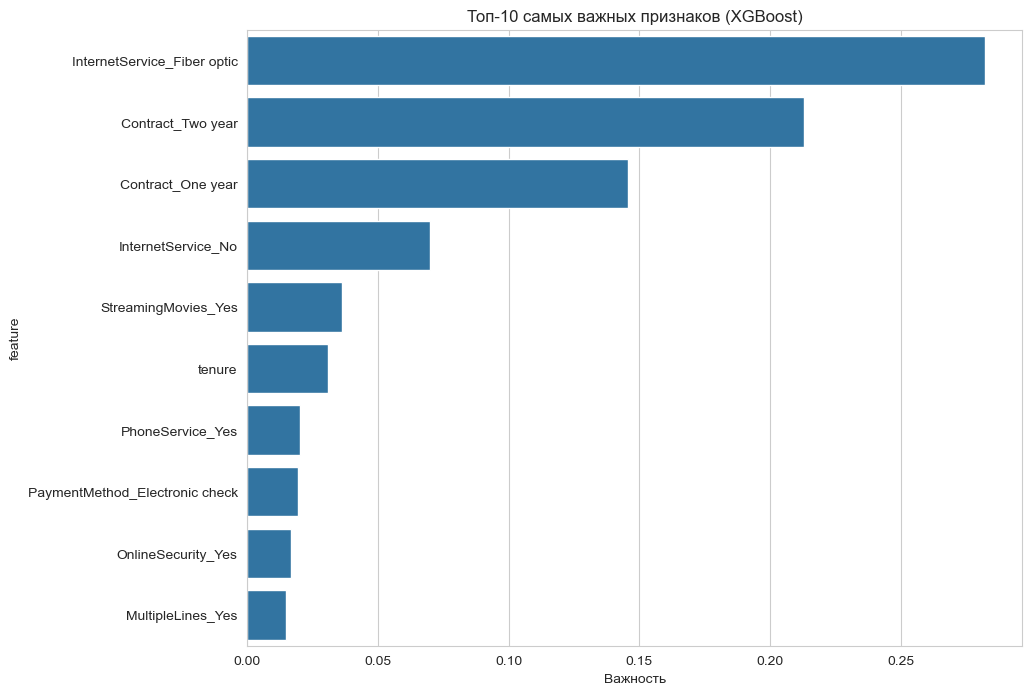

In [53]:
# Feature Importance для XGBoost
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
plt.title('Топ-10 самых важных признаков (XGBoost)')
plt.xlabel('Важность')
plt.show()

In [55]:
# Вывод топ-5 признаков
print("Топ-5 факторов, влияющих на отток клиентов:")
print(feature_importance.head(5))

Топ-5 факторов, влияющих на отток клиентов:
                        feature  importance
11  InternetService_Fiber optic    0.282459
26            Contract_Two year    0.212968
25            Contract_One year    0.145768
12           InternetService_No    0.069714
24          StreamingMovies_Yes    0.036138


In [57]:
import joblib

# Сохраняем лучшую модель (XGBoost)
joblib.dump(xgb, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Модель и скейлер сохранены!")

Модель и скейлер сохранены!


In [59]:
print("""
===== ВЫВОДЫ ПО ПРОЕКТУ =====
1. Лучшая модель: XGBoost (ROC-AUC ≈ 0.84)
2. Ключевые факторы оттока:
   - Стаж клиента (tenure) — чем меньше, тем выше риск
   - Тип контракта (месячный) — самые рискованные
   - Отсутствие доп. услуг (PhoneService, InternetService)
3. Рекомендации бизнесу:
   - Предлагать долгосрочные контракты со скидкой
   - Увеличить retention-программы для новых клиентов
   - Стимулировать подключение доп. услуг
""")


===== ВЫВОДЫ ПО ПРОЕКТУ =====
1. Лучшая модель: XGBoost (ROC-AUC ≈ 0.84)
2. Ключевые факторы оттока:
   - Стаж клиента (tenure) — чем меньше, тем выше риск
   - Тип контракта (месячный) — самые рискованные
   - Отсутствие доп. услуг (PhoneService, InternetService)
3. Рекомендации бизнесу:
   - Предлагать долгосрочные контракты со скидкой
   - Увеличить retention-программы для новых клиентов
   - Стимулировать подключение доп. услуг

